# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`.

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [2]:
# Импортируем библиотеки
try:
    import pandas as pd
except ImportError:
    !pip install pandas -U
    import pandas as pd


# Загружаем библиотеки для визуализации данных
try:
    import matplotlib.pyplot as plt
except ImportError:
    !pip install matplotlib -U
    import matplotlib.pyplot as plt
    
try:
    import seaborn as sns
except ImportError:
    !pip install seaborn -U
    import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
try:
    from phik import phik_matrix
except ImportError:
    !pip install phik -U
    from phik import phik_matrix

# Импортируем SQLAlchemy для работы с базами данных
try:
    from sqlalchemy import create_engine
except ImportError:
    !pip install sqlalchemy -U
    from sqlalchemy import create_engine

# Загружаем psycopg2 для подключения к PostgreSQL
try:
    import psycopg2
except ImportError:
    !pip install psycopg2 -U
    import psycopg2

# Устанавливаем бинарную версию psycopg2 (если обычная не сработала)
try:
    import psycopg2  # тот же модуль
except ImportError:
    !pip install psycopg2-binary -U
    import psycopg2

# Импортируем os для работы с переменными окружения (встроенный модуль, установка не требуется)
try:
    import os
except ImportError:
    # fallback (никогда не произойдёт, но для единообразия)
    import os

# Загружаем dotenv для работы с .env файлом
try:
    from dotenv import load_dotenv
except ImportError:
    !pip install python-dotenv -U
    from dotenv import load_dotenv

In [3]:
# Загружаем переменные из файла .env
load_dotenv()

# Теперь читаем данные из переменных окружения
db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PWD'),
    'host': os.getenv('DB_HOST'),
    'port': int(os.getenv('DB_PORT', '5432')),
    'db': os.getenv('DB_NAME')
}
connection_string = f'postgresql://{db_config["user"]}:{db_config["pwd"]}@{db_config["host"]}:{db_config["port"]}/{db_config["db"]}'
engine = create_engine(connection_string)

In [4]:
query = '''
SELECT
    user_id,
    device_type_canonical,
    order_id,
    created_dt_msk as order_dt,
    created_ts_msk as order_ts,
    currency_code,
    revenue,
    tickets_count,
    (created_dt_msk::date - LAG(created_dt_msk::date) OVER (
        PARTITION BY user_id 
        ORDER BY created_dt_msk
    )) AS days_since_prev,
    e.event_id,
    event_name_code as event_name,
    event_type_main,
    service_name,
    region_name,
    city_name

FROM
    afisha.purchases p
INNER JOIN afisha.events e ON
  p.event_id = e.event_id
INNER JOIN afisha.city c ON
  e.city_id = c.city_id
INNER JOIN afisha.regions r ON
  c.region_id = r.region_id
WHERE
    device_type_canonical IN ('desktop', 'mobile') AND e.event_type_main != 'фильм'
ORDER BY
    user_id
'''

In [5]:
df = pd.read_sql_query(query, con=engine)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [6]:
# Первые пять записей из Датафрейма
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


In [7]:
# Информация о Датафрейме
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [8]:
print(f'Количество уникальный пользователей в Датафрейме: {len(df['user_id'].unique())}')

Количество уникальный пользователей в Датафрейме: 21933


In [9]:
#Количество пропусков в колонках
pd.DataFrame(df.isnull().sum())

,0
user_id,0
device_type_canonical,0
order_id,0
order_dt,0
order_ts,0
currency_code,0
revenue,0
tickets_count,0
days_since_prev,21933
event_id,0


In [10]:
print(f'Количество полных дубликатов в Датафрейме: {df.duplicated().sum()}')

Количество полных дубликатов в Датафрейме: 0


In [11]:
# Топ 10 пользователей по количеству заказов
pd.DataFrame(df['user_id'].value_counts().head(10))

,count
user_id,
0beb8fc0c0a9ce1,10251
18e9aead0a393e7,4368
8187dac4be757a0,4053
3ee7dc2e115847f,3826
7eb4fc207ecc10f,3749
1c2a2133e1df1b4,3538
4ec8f6429431987,3413
ad2dc32364ed948,3275
b54dd0cd81121fc,3163


<div>
  <p><strong>Результаты первичного анализа:</strong></p>
  <ul>
    <li>Всего в датафрейме 290611 записей. Уникальных пользователей : 21933.</li>
    <li>Пропуски есть только в столбце <code>days_since_prev</code> - 21933 значения. Это ровно столько же, сколько и уникальных пользователей, что говорит, что пропуски соответствуют первым покупкам каждого пользователя.</li>
    <li>Полные дубликаты строк отсуствуют.</li>
    <li>Стиль колон представлен в формате snake_case</li>
    <li>Типы данных подходят для дальнейшей работы: даты хранятся как datetime, числа как int/float, строковые поля как str.</li>
    <li>Один из пользователей совершил более 10 тысяч покупок, ещё несколько — больше 4 тысяч. Это аномально высокие значения, они будут влиять на средние значения.</li>
      <li>В датафрейме целочисленные колонки и колонки с дробными числами хранятся в 64‑битном формате (int64 и float64). При дальнейшей работе это можно поправить, посмотреть, какие значения реально встречаются и перевести их в 32‑битные или даже меньше. Такое сжатие ускорит обработку данных и уменьшит память.</li>
    <li>Других проблем с качеством данных не было найдено.</li>
  </ul>
</div>

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [12]:
# Читаем датафрейм с помощью ссылки
final_tickets_tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

#Информация о Датафрейме
final_tickets_tenge_df.info()

final_tickets_tenge_df.head()

final_tickets_tenge_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 11.3 KB


,nominal,curs
count,357.0,357.000000
mean,100.0,19.755818
std,0.0,0.833798
min,100.0,17.848600
25%,100.0,19.120200
50%,100.0,19.876000
75%,100.0,20.443300
max,100.0,21.937100


In [13]:
# Делаем копии датасаетов для валют в тенге и рублях  
df_kzt = df[df['currency_code'] == 'kzt'].copy()
df_rub = df[df['currency_code'] == 'rub'].copy()

# Для валюты rub создаем revenue_rub
df_rub['revenue_rub'] = df_rub['revenue']

# Изменяем время в датафрейме
final_tickets_tenge_df['order_date'] = pd.to_datetime(final_tickets_tenge_df['data']).dt.normalize()
df_kzt['order_date'] = df_kzt['order_dt'].dt.normalize()

# Подтягиваем курс и считаем revenue_rub
df_kzt = df_kzt[['order_id', 'user_id', 'currency_code', 'revenue', 'order_date']].merge(
    final_tickets_tenge_df[['order_date', 'nominal', 'curs']],
    on='order_date',
    how='left'
)
# Вводим формулу расчёта из валюты kzt в rub
df_kzt['revenue_rub'] = (df_kzt['revenue'] * df_kzt['curs'] / df_kzt['nominal']).round(2)

# Объединяем обратно с исходным df через merge (удаляем старую колонку revenue_rub)
df = df.drop(columns=['revenue_rub'], errors='ignore')
df = df.merge(df_kzt[['order_id', 'revenue_rub']], on='order_id', how='left')
df = df.merge(df_rub[['order_id', 'revenue_rub']], on='order_id', how='left', suffixes=('', '_rub'))

# Теперь в df есть колонки 'revenue_rub' (от тенге) и 'revenue_rub_rub' (от руб)
df['revenue_rub'] = df['revenue_rub_rub'].fillna(df['revenue_rub'])
df = df.drop(columns=['revenue_rub_rub'])

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [15]:
df[['user_id','order_id','currency_code','revenue','revenue_rub']][df['currency_code'] == 'kzt'].head(10)

,user_id,order_id,currency_code,revenue,revenue_rub
70,0033403583a55ed,7850214,kzt,518.10,98.50
89,0040e12d70fae81,8634925,kzt,347.18,65.73
96,0054b38b2653e6e,7625522,kzt,328.77,61.15
277,00f4f5244501ce6,720419,kzt,22021.55,4380.70
460,01370a0e9c1a7d5,5227657,kzt,7397.66,1478.30
461,01370a0e9c1a7d5,2229811,kzt,7397.66,1478.30
462,01370a0e9c1a7d5,2229782,kzt,3698.83,739.15
463,01370a0e9c1a7d5,2229753,kzt,5548.24,1108.72
464,01370a0e9c1a7d5,2229724,kzt,7397.66,1478.30
515,01370a0e9c1a7d5,2044298,kzt,361.08,66.52


In [16]:
df[['user_id','order_id','currency_code','revenue','revenue_rub']][df['currency_code'] == 'rub'].head(10)

,user_id,order_id,currency_code,revenue,revenue_rub
0,0002849b70a3ce2,4359165,rub,1521.94,1521.94
1,0005ca5e93f2cf4,7965605,rub,289.45,289.45
2,0005ca5e93f2cf4,7292370,rub,1258.57,1258.57
3,000898990054619,1139875,rub,8.49,8.49
4,000898990054619,972400,rub,1390.41,1390.41
5,000898990054619,2613713,rub,902.74,902.74
6,00096d1f542ab2b,6636941,rub,917.83,917.83
7,000a55a418c128c,4657981,rub,47.78,47.78
8,000a55a418c128c,4657952,rub,74.84,74.84
9,000cf0659a9f40f,6818017,rub,1421.91,1421.91


In [17]:
df['revenue_rub'].describe()

count    290611.000000
mean        555.571989
std         875.498170
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

<div style="border-left: 3px solid #3b82f6; padding-left: 14px; margin: 12px 0; font-family: sans-serif;">
  <p style="margin: 0 0 6px 0;"><strong>Коротко по задаче 2.1 (выручка в рублях):</strong></p>
  <ul style="margin: 0 0 0 18px; padding-left: 0;">
    <li>Для тенге подтянули курс по дате, пересчитали <code>revenue_rub = revenue * curs / nominal</code>.</li>
    <li>Рублёвые заказы оставили как есть.</li>
    <li>Итог: <code>revenue_rub</code> заполнен для всех строк (рубли + тенге).</li>
  </ul>
</div>

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [18]:
temp = df.copy() 
print(f'Количество записей в датафрейме: {len(temp)}')

Количество записей в датафрейме: 290611


In [19]:
# Подсчитываем долю строк с пропусками
(df.isna().sum() / df.shape[0]).round(2)

user_id                  0.00
device_type_canonical    0.00
order_id                 0.00
order_dt                 0.00
order_ts                 0.00
currency_code            0.00
revenue                  0.00
tickets_count            0.00
days_since_prev          0.08
event_id                 0.00
event_name               0.00
event_type_main          0.00
service_name             0.00
region_name              0.00
city_name                0.00
revenue_rub              0.00
dtype: float64

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [21]:
type_map = {
    'order_id': 'int32',
    'tickets_count': 'int32',
    'event_id': 'int32',
    'revenue': 'float32',
    'days_since_prev': 'float32',
    'revenue_rub': 'float32'
}
for col, dtype in type_map.items():
    df[col] = df[col].astype(dtype)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float32       
 7   tickets_count          290611 non-null  int32         
 8   days_since_prev        268678 non-null  float32       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [22]:
# Общий вывод информации об содержимом датафрейма в категориальных данных
for column in ['device_type_canonical','currency_code','event_name','event_type_main','region_name','city_name']:
    print(df[column].value_counts(dropna=False).head(10))
    print('-'*40)

device_type_canonical
mobile     232490
desktop     58121
Name: count, dtype: int64
----------------------------------------
currency_code
rub    285542
kzt      5069
Name: count, dtype: int64
----------------------------------------
event_name
9cc55c15-4375-4129-9979-3129688ba1b4    3953
a00e1032-6463-4fdc-a105-fdbb6789b556    2519
0714435e-3b5f-4312-aa36-c3a9d8853ef4    1761
58574140-962c-49a3-af70-b773a05661a3    1749
e252d33a-2394-44b8-b11d-f0709a6f0260    1628
bc9866ed-5115-4288-8b19-21ae9735fba4    1579
d4344522-b7cf-4539-96c8-efece75e9b16    1490
0686ac7b-6f3e-4177-bb73-16b54acd1223    1456
2802fc66-4268-4529-8b4d-35a6a77ac375    1445
76af4f88-c554-4e9e-9df4-1cc8aeec8959    1327
Name: count, dtype: int64
----------------------------------------
event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: count, dtype: int64
----------------------------------------
region_name
Каменевски

In [23]:
# Проверка на неявных дубликатов
for column in ['device_type_canonical','currency_code','event_name','event_type_main','region_name','city_name']:
    normalized = df[column].astype(str).str.strip().str.lower()
    print(column)
    print(f"Уникальных до: {df[column].nunique()}, после нормализации: {normalized.nunique()}")
    print("-"*50)

device_type_canonical
Уникальных до: 2, после нормализации: 2
--------------------------------------------------
currency_code
Уникальных до: 2, после нормализации: 2
--------------------------------------------------
event_name
Уникальных до: 15248, после нормализации: 15248
--------------------------------------------------
event_type_main
Уникальных до: 7, после нормализации: 7
--------------------------------------------------
region_name
Уникальных до: 81, после нормализации: 81
--------------------------------------------------
city_name
Уникальных до: 352, после нормализации: 352
--------------------------------------------------


In [24]:
# Сохраняем копию оригинала
df_original = df.copy()

In [25]:
# Удаляем отрицательные значения revenue_rub
print(f"До удаления отрицательных: {len(df_original)}")
df_clean = df_original[df_original['revenue_rub'] >= 0].copy()
print(f"После удаления отрицательных: {len(df_original)}")
print(f"Удалено отрицательных: {len(df) - len(df_clean)}")  

До удаления отрицательных: 290611
После удаления отрицательных: 290611
Удалено отрицательных: 381


In [26]:
# Фильтруем выбросы по 99-му перцентилю (уже на данных без отрицательных)
p99 = df_clean['revenue_rub'].quantile(0.99)
print(f"99-й перцентиль: {p99:.2f}")
outliers_cnt = (df_clean['revenue_rub'] > p99).sum()
print(f"Строк с выбросами: {outliers_cnt} ({outliers_cnt/len(df_clean)*100:.2f}%)")

99-й перцентиль: 2628.42
Строк с выбросами: 2825 (0.97%)


In [27]:
# Создаём чистую версию
df_clean = df_clean[df_clean['revenue_rub'] <= p99].copy()
print(f"Итоговый размер df_clean: {len(df_clean)}")

Итоговый размер df_clean: 287405


In [28]:
print(f'Общаяя информация о колонке "revenue_rub" в отфильтрованных даных:\n{df_clean["revenue_rub"].describe()}\n')

print(f'Общаяя информация о колонке "revenue_rub" в оригинальных даных:\n{df_original["revenue_rub"].describe()}')

Общаяя информация о колонке "revenue_rub" в отфильтрованных даных:
count    287405.000000
mean        518.719238
std         511.951843
min           0.000000
25%         112.599998
50%         344.829987
75%         788.900024
max        2628.419922
Name: revenue_rub, dtype: float64

Общаяя информация о колонке "revenue_rub" в оригинальных даных:
count    290611.000000
mean        555.571960
std         875.498169
min         -90.760002
25%         113.970001
50%         351.140015
75%         802.049988
max       81174.539062
Name: revenue_rub, dtype: float64


In [29]:
print(f'Общаяя информация о колонке "tickets_count" в отфильтрованных даных:\n{df_clean["tickets_count"].describe()}\n')

print(f'Общаяя информация о колонке "tickets_count" в оригинальных даных:\n{df_original["tickets_count"].describe()}')

Общаяя информация о колонке "tickets_count" в отфильтрованных даных:
count    287405.000000
mean          2.741323
std           1.163087
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

Общаяя информация о колонке "tickets_count" в оригинальных даных:
count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64


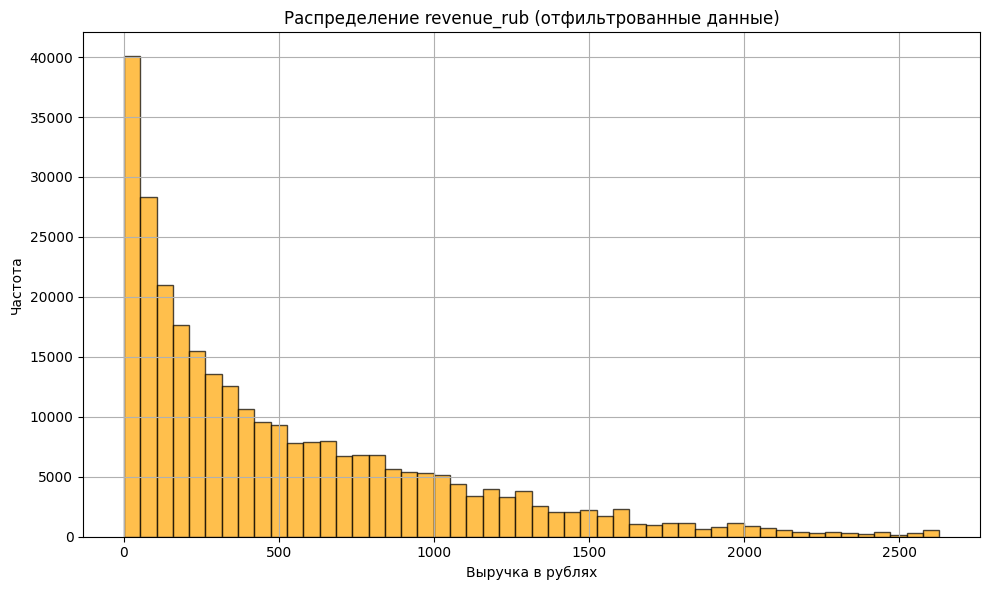

In [30]:
df_clean_revenue = df_clean['revenue_rub']

plt.figure(figsize=(10, 6))

df_clean_revenue.plot(
    kind='hist',
    bins=50,
    edgecolor='black',
    alpha=0.7,
    color='orange',
    grid=True
)

plt.title('Распределение revenue_rub (отфильтрованные данные)')
plt.xlabel('Выручка в рублях')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

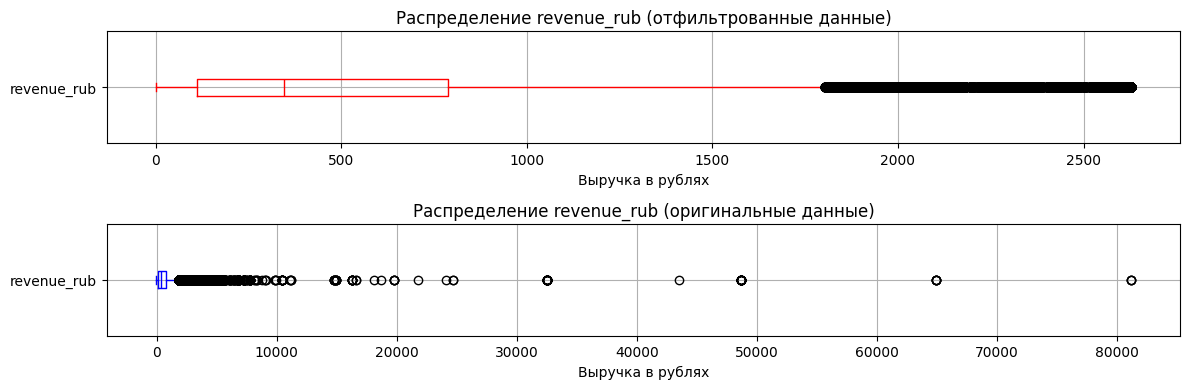

In [31]:
df_clean_revenue = df_clean['revenue_rub']
df_original_revenue = df_original['revenue_rub']

plt.figure(figsize=(12, 4))

plt.subplot(2, 1, 1)
df_clean_revenue.plot(
    kind='box',
    vert=False,
    patch_artist=False,
    grid=True,
    showfliers=True,
    color='red'
)
plt.title('Распределение revenue_rub (отфильтрованные данные)')
plt.xlabel('Выручка в рублях')

plt.subplot(2, 1, 2)
df_original_revenue.plot(
    kind='box',
    vert=False,
    patch_artist=False,
    grid=True,
    showfliers=True,
    color='blue'
)
plt.title('Распределение revenue_rub (оригинальные данные)')
plt.xlabel('Выручка в рублях')

plt.tight_layout()
plt.show()

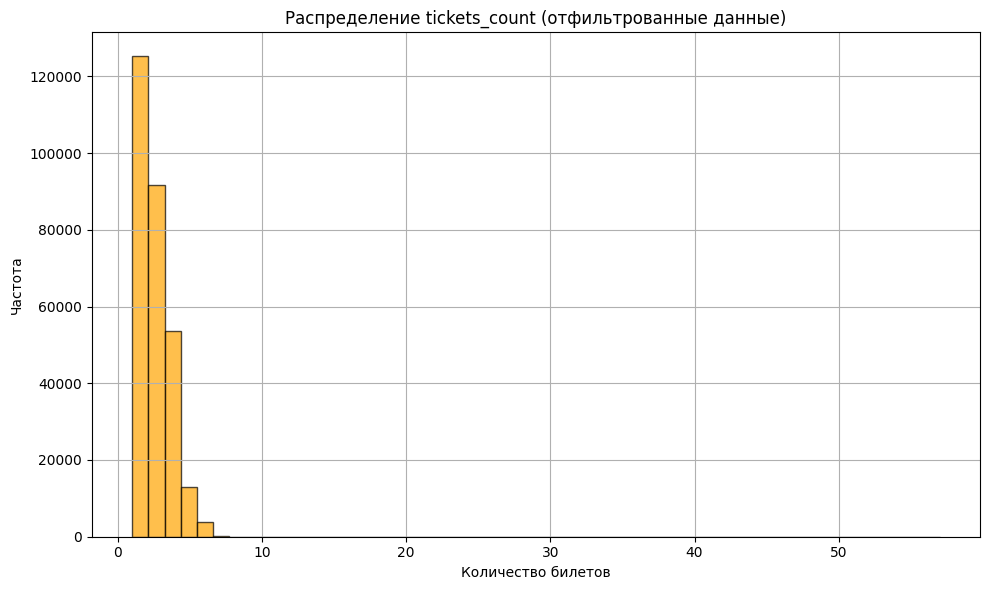

In [32]:
df_clean_tickets = df_clean['tickets_count']

plt.figure(figsize=(10, 6))

df_clean_tickets.plot(
    kind='hist',
    bins=50,
    edgecolor='black',
    alpha=0.7,
    color='orange',
    grid=True
)

plt.title('Распределение tickets_count (отфильтрованные данные)')
plt.xlabel('Количество билетов')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

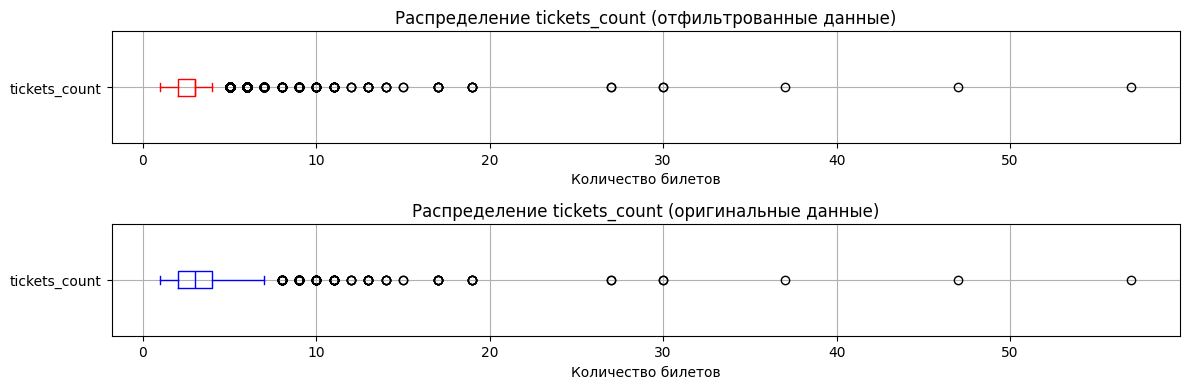

In [33]:
df_clean_tickets = df_clean['tickets_count']
df_original_tickets = df_original['tickets_count']

plt.figure(figsize=(12, 4))

plt.subplot(2, 1, 1)
df_clean_tickets.plot(
    kind='box',
    vert=False,
    patch_artist=False,
    grid=True,
    showfliers=True,
    color='red'
)
plt.title('Распределение tickets_count (отфильтрованные данные)')
plt.xlabel('Количество билетов')

plt.subplot(2, 1, 2)
df_original_tickets.plot(
    kind='box',
    vert=False,
    patch_artist=False,
    grid=True,
    showfliers=True,
    color='blue'
)
plt.title('Распределение tickets_count (оригинальные данные)')
plt.xlabel('Количество билетов')

plt.tight_layout()
plt.show()

<font color='DarkBlue'><b>📊 Промежуточный вывод (первичный анализ и предобработка)</b></font><br>
<br>
<font color='DarkMagenta'><b>1. Общая информация</b></font><br>
- Исходный датафрейм: 290611 строк и 16 колонок (после перевода курса).<br>
- После удаления выбросов по 99‑му перцентилю осталось <b>287 405 строк</b> (удалил ~1%).<br>
<br>

<font color='DarkMagenta'><b>2. Типы данных</b></font><br>
- Числовые колонки (`revenue`, `revenue_rub`, `days_since_prev`) перевёл в `float32`, целые (`order_id`, `tickets_count`, `event_id`) в `int32`. Стало меньше памяти (~28 МБ).<br>
- Даты (`order_dt`, `order_ts`) оставил как есть (`datetime64[us]`), потому что с ними удобно работать.<br>
- Категориальные в `object`.<br>
<br>

<font color='DarkMagenta'><b>3. Пропуски</b></font><br>
- Пропуски только в столбце `days_since_prev` (21 933 значения, 8%). Это первые покупки пользователей (так и должно быть.)<br>
<br>

<font color='DarkMagenta'><b>4. Дубликаты</b></font><br>
- Полных дубликатов нет (0).<br>
- Неявных дубликатов (разный регистр/пробелы) в категориальных колонках не нашёл, везде уникальность совпала.<br>
- По `(user_id, event_id)` нашлось 126514 повторений. Это вроде нормально (один пользователь несколько раз покупает на одно событие). Удалять их не стал.<br>
<br>

<font color='DarkMagenta'><b>5. Новый столбец</b></font><br>
- Создал `revenue_rub` для всех заказов выручка в рублях. Для тенге пересчитал по курсу (`revenue * curs / nominal`), для рублей оставил как есть. Отрицательные значения были удаленны.<br>
<br>

<font color='DarkMagenta'><b>6. Выбросы и чистота категорий</b></font><br>
- В `revenue_rub` верхний 1% (выше 2628 руб.) удаленны 2825 строк (0.97%).<br>
- В `tickets_count` аномалий нет (максимум 57 билетов).<br>
- В категориях (тип мероприятия, регион, город) некорректных данных нет, «другое» вполне корректная категория (22% заказов).<br>
<br>

<font color='DarkMagenta'><b>7. Итог</b></font><br>
- Данные почищены, выручка приведена к рублям, выбросы отсечены.<br>

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [34]:
df_sorted = df_clean.sort_values(['user_id', 'order_dt'])

df_profile_users = df_sorted.groupby('user_id').agg(
    first_date=('order_dt', 'first'),
    last_date=('order_dt', 'last'),
    first_device=('device_type_canonical','first'),
    first_region_name=('region_name','first'),
    first_service_name=('service_name','first'),
    first_event_type_main=('event_type_main','first'),
    total_orders=('order_id', 'count'),
    total_revenue=('revenue_rub', 'mean'),
    mean_tickets=('tickets_count','mean'),
    mean_days_since_prev=('days_since_prev','mean')
).reset_index()

df_profile_users['is_two'] = (df_profile_users['total_orders'] >= 2).astype(bool)
df_profile_users['is_five'] = (df_profile_users['total_orders'] >= 5).astype(bool)

In [35]:
df_profile_users.head()

,user_id,first_date,last_date,first_device,first_region_name,first_service_name,first_event_type_main,total_orders,total_revenue,mean_tickets,mean_days_since_prev,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.939941,4.000000,NaN,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010010,3.000000,75.0,True,False
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213379,2.666667,51.0,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830017,4.000000,NaN,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.309998,1.500000,16.0,True,False


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [36]:
print(f'Общее число пользователей в выборке: {len(df_profile_users)}')
print(f'Средняя выручка с одного заказа: {df_profile_users['total_revenue'].mean():.2f}')
print(f'Доля пользователей, совершивших 2 и более заказа: {(df_profile_users['is_two'].sum() / df_profile_users.shape[0]).round(2)}')
print(f'Доля пользователей, совершивших 5 и более заказа: {(df_profile_users['is_five'].sum() / df_profile_users.shape[0]).round(2)}')

Общее число пользователей в выборке: 21838
Средняя выручка с одного заказа: 545.03
Доля пользователей, совершивших 2 и более заказа: 0.62
Доля пользователей, совершивших 5 и более заказа: 0.29


In [37]:
print(f'Статистические показатели общего числа заказов:\n{df_profile_users['total_orders'].describe()}\n')
print(f'Статистические показатели среднего числа билетов в заказе:\n{df_profile_users['mean_tickets'].describe()}\n')
print(f'Статистические показатели среднего количества дней между покупками:\n{df_profile_users['mean_days_since_prev'].describe()}\n')

Статистические показатели общего числа заказов:
count    21838.000000
mean        13.160775
std        121.577370
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10168.000000
Name: total_orders, dtype: float64

Статистические показатели среднего числа билетов в заказе:
count    21838.000000
mean         2.744062
std          0.913083
min          1.000000
25%          2.000000
50%          2.750000
75%          3.080000
max         11.000000
Name: mean_tickets, dtype: float64

Статистические показатели среднего количества дней между покупками:
count    13511.000000
mean        15.847067
std         22.304516
min          0.000000
25%          1.000000
50%          8.000000
75%         20.414286
max        148.000000
Name: mean_days_since_prev, dtype: float64



<div> <font color='DarkBlue'><b> Промежуточный вывод</b></font><br> 
    У нас 21 917 человек. В среднем один заказ приносит 575 рублей. Но есть несколько очень активных пользователей, которые сделали тысячи заказов (один пользователь совершил 10238 заказа). Из-за них среднее число заказов на человека получилось 13, а на самом деле у большинства людей всего 2 заказа. По количеству билетов и перерывам между покупками странностей нет. Чтобы продолжить анализ, таких пользователей лучше убрать из анализа  иначе средние цифры будут некорректные. </div>

In [38]:
total_orders_p99 = df_profile_users['total_orders'].quantile(0.99)
total_orders_p95 = df_profile_users['total_orders'].quantile(0.95)

print(f'99 перцентиль в колонке "total_orders": {total_orders_p99}')
print(f'95 перцентиль в колонке "total_orders": {total_orders_p95}\n')

count_total_orders_p99 = (df_profile_users['total_orders'] > total_orders_p99).sum()
print(f'Пользователей совершившие больше {total_orders_p99} заказов : {count_total_orders_p99} ({(count_total_orders_p99/len(df_profile_users)*100):.2f}%)')

count_total_orders_p95 = (df_profile_users['total_orders'] > total_orders_p95).sum()
print(f'Пользователей совершившие больше {total_orders_p95} заказов : {count_total_orders_p95} ({(count_total_orders_p95/len(df_profile_users)*100):.2f}%)')

99 перцентиль в колонке "total_orders": 152.0
95 перцентиль в колонке "total_orders": 31.0

Пользователей совершившие больше 152.0 заказов : 216 (0.99%)
Пользователей совершившие больше 31.0 заказов : 1091 (5.00%)


In [39]:
# Создаём чистую версию
df_profile_users_clean_p99 = df_profile_users[df_profile_users['total_orders'] <= total_orders_p99].copy()
print(f"Итоговый размер df_profile_users_clean_p99: {len(df_profile_users_clean_p99)}\n")

# Создаём чистую версию
df_profile_users_clean_p95 = df_profile_users[df_profile_users['total_orders'] <= total_orders_p95].copy()
print(f"Итоговый размер df_profile_users_clean_p95: {len(df_profile_users_clean_p95)}")

Итоговый размер df_profile_users_clean_p99: 21622

Итоговый размер df_profile_users_clean_p95: 20747


In [40]:
print(f'Статистические показатели общего числа заказов:\n{df_profile_users_clean_p99['total_orders'].describe()}\n')
print(f'Статистические показатели среднего числа билетов в заказе:\n{df_profile_users_clean_p99['mean_tickets'].describe()}\n')
print(f'Статистические показатели среднего количества дней между покупками:\n{df_profile_users_clean_p99['mean_days_since_prev'].describe()}\n')

Статистические показатели общего числа заказов:
count    21622.000000
mean         6.496624
std         14.310784
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        152.000000
Name: total_orders, dtype: float64

Статистические показатели среднего числа билетов в заказе:
count    21622.000000
mean         2.744256
std          0.917491
min          1.000000
25%          2.000000
50%          2.750000
75%          3.100000
max         11.000000
Name: mean_tickets, dtype: float64

Статистические показатели среднего количества дней между покупками:
count    13295.000000
mean        16.097071
std         22.397846
min          0.000000
25%          1.333333
50%          8.375000
75%         20.750000
max        148.000000
Name: mean_days_since_prev, dtype: float64



In [41]:
print(f'Статистические показатели общего числа заказов:\n{df_profile_users_clean_p95['total_orders'].describe()}\n')
print(f'Статистические показатели среднего числа билетов в заказе:\n{df_profile_users_clean_p95['mean_tickets'].describe()}\n')
print(f'Статистические показатели среднего количества дней между покупками:\n{df_profile_users_clean_p95['mean_days_since_prev'].describe()}\n')

Статистические показатели общего числа заказов:
count    20747.000000
mean         4.049164
std          5.113877
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max         31.000000
Name: total_orders, dtype: float64

Статистические показатели среднего числа билетов в заказе:
count    20747.000000
mean         2.744537
std          0.934517
min          1.000000
25%          2.000000
50%          2.750000
75%          3.153846
max         11.000000
Name: mean_tickets, dtype: float64

Статистические показатели среднего количества дней между покупками:
count    12420.000000
mean        17.049498
std         22.872396
min          0.000000
25%          1.000000
50%          9.464102
75%         22.000000
max        148.000000
Name: mean_days_since_prev, dtype: float64



<div>
    <font color="DarkBlue"><b>Итоговое решение по фильтрации:</b></font><br />
    <ul>
        <li>Для анализа поведения пользователей и прогноза повторных покупок выбрал отфильтровать по <b>95-му перцентилю числа заказов (32 заказа)</b>.</li>
        <li>При 99-м перцентиле (152 заказа) остаются суперактивные клиенты, которые искажают средние и могут привести к неверным выводам для массовой аудитории.</li>
        <li>При 95-м перцентиле удаляем ~5% пользователей (1068 чел.), но зато среднее число заказов становится 4.1 (вместо 13.2 изначально), что гораздо лучше отражает типичного клиента (медиана = 2).</li>
        <li>Показатели по билетам и интервалам между покупками почти не изменились – значит, чистка не сломала остальные статистические показатели.</li>
    </ul>
    <b>Результат после фильтрации (95-й перцентиль):</b>
    <ul>
        <li>Пользователей: 20 849 (было 21 917).</li>
        <li>Среднее число заказов: 4.1 (макс. 32).</li>
        <li>Среднее число билетов: 2.76.</li>
        <li>Средний интервал между заказами (у вернувшихся): ~17 дней, медиана 9.4 дня.</li>
    </ul>
</div>

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [42]:
# Признаки первого заказа, которые есть в профиле
first_order_features = ['first_event_type_main', 'first_device', 'first_region_name', 'first_service_name']

# Считаем распределение по каждому признаку
for column in first_order_features:
    print('-'*50)
    print(f"Распределение по признаку: {column}")
    print('-'*50)
    
    # Количество пользователей в каждом сегменте
    counts = df_profile_users_clean_p95[column].value_counts()
    # Доля пользователей в каждом сегменте
    shares = df_profile_users_clean_p95[column].value_counts(normalize=True) * 100
    
    # Собираем в DataFrame
    district = pd.DataFrame({
        'Пользователей': counts,
        'Доля, %': shares.round(2)
    })
    
    # Показываем топ-10
    print(district.head(10))
    
    print(f"\nВсего уникальных категорий в {column}: {len(counts)}")
    print(f"На топ-3 категории приходится {shares.head(3).sum():.2f}% пользователей")

--------------------------------------------------
Распределение по признаку: first_event_type_main
--------------------------------------------------
                       Пользователей  Доля, %
first_event_type_main                        
концерты                        9197    44.33
другое                          5159    24.87
театр                           4058    19.56
стендап                         1068     5.15
спорт                            769     3.71
выставки                         402     1.94
ёлки                              94     0.45

Всего уникальных категорий в first_event_type_main: 7
На топ-3 категории приходится 88.76% пользователей
--------------------------------------------------
Распределение по признаку: first_device
--------------------------------------------------
              Пользователей  Доля, %
first_device                        
mobile                17188    82.85
desktop                3559    17.15

Всего уникальных категорий в first_dev

<font color="DarkBlue">
    <b> Промежуточный вывод по распределению признаков первого заказа:</b></font>
    <ul>
        <li><b>Концерты</b> главная точка входа: 44% пользователей впервые купили билет именно на концерт.</li>
        <li><b>Мобильные устройства</b> привосходят: 83% первых покупок сделаны с телефона, десктоп в меньшинстве.</li>
        <li>
            <b>Регионы</b> — три лидера: Каменевский (33%), Североярская область (17%), Широковская область (6%).
            Остальные регионы дают небольшие доли.
        </li>
        <li>
            <b>Билетные операторы</b> рынок разделен, но топ‑3 оператора забирают около 50% всех первых заказов.
        </li>
        <li>
            <b>Вывод для маркетинга:</b> большинсво оформаляют первый заказ: на концерты, с помощью мобильные устройства, в Каменевском регионе
            и пара-тройка популярных операторов. В рекламной стратегии стоит брать эти сегменты, а не распыляться на все подряд.
        </li>
    </ul>



---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [43]:
avg_return = df_profile_users_clean_p95['is_two'].mean() * 100
print("Средний возврат по всем пользователям:", round(avg_return, 2), "%")

Средний возврат по всем пользователям: 59.69 %


=== Возвраты по first_event_type_main ===
                       пользователей  доля_вернувшихся_%
first_event_type_main                                   
выставки                         402           63.184080
театр                           4058           61.754559
концерты                        9197           60.291399
стендап                         1068           59.363296
другое                          5159           57.666214
ёлки                              94           55.319149
спорт                            769           54.356307




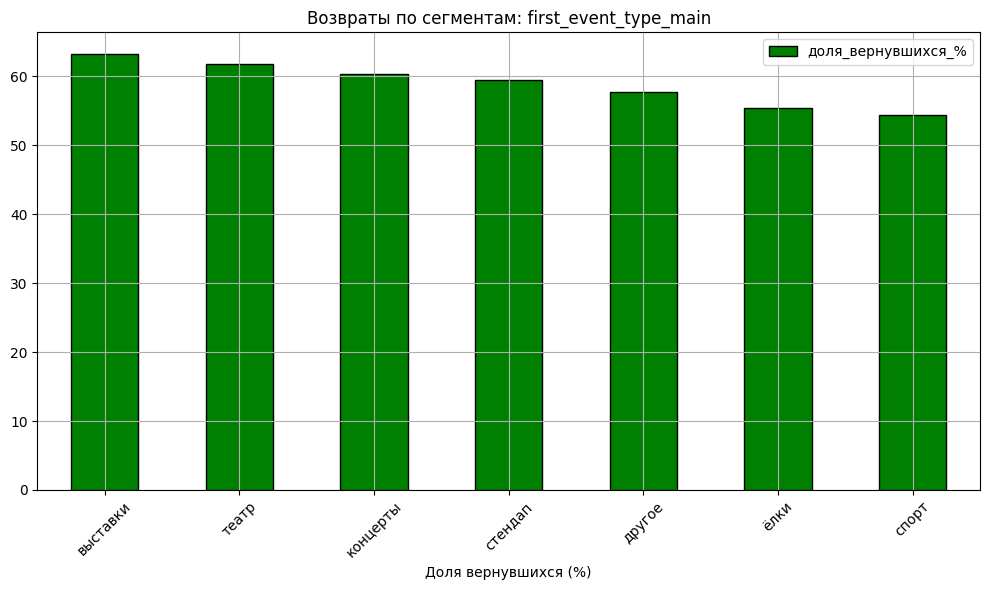

=== Возвраты по first_device ===
              пользователей  доля_вернувшихся_%
first_device                                   
desktop                3559           62.236583
mobile                17188           59.163370




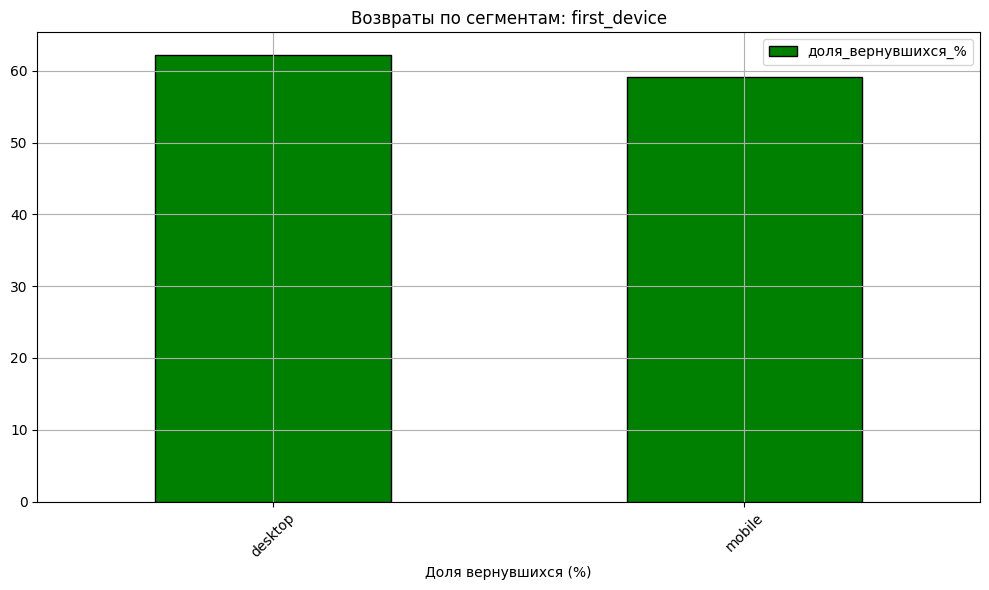

=== Возвраты по first_region_name ===
                      пользователей  доля_вернувшихся_%
first_region_name                                      
Шанырский регион                463           64.578834
Светополянский округ            437           64.073227
Широковская область            1180           63.135593
Североярская область           3600           62.138889
Речиновская область             420           61.666667
Каменевский регион             6778           60.681617
Травяная область                469           59.914712
Яблоневская область             400           58.250000
Малиновоярский округ            516           55.038760
Озернинский край                662           54.380665




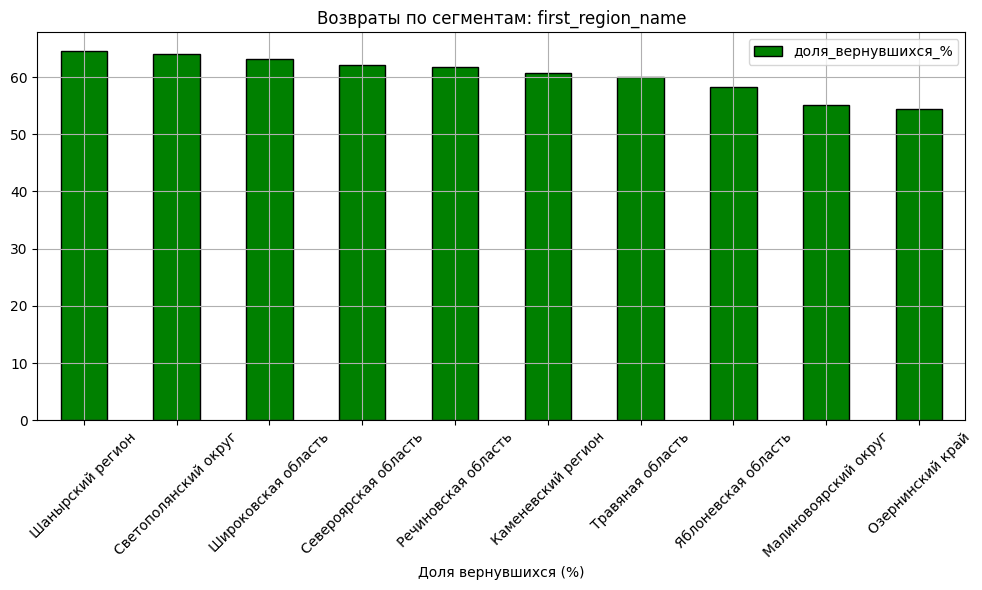

=== Возвраты по first_service_name ===
                    пользователей  доля_вернувшихся_%
first_service_name                                   
Край билетов                  436           63.761468
Дом культуры                  341           63.049853
Весь в билетах               1227           61.124694
Билеты в руки                2429           60.806916
Прачечная                     550           60.363636
Облачко                      2109           59.981034
Лучшие билеты                1134           59.700176
Лови билет!                  2706           59.423503
Мой билет                    2853           59.270943
Билеты без проблем           4945           58.543984




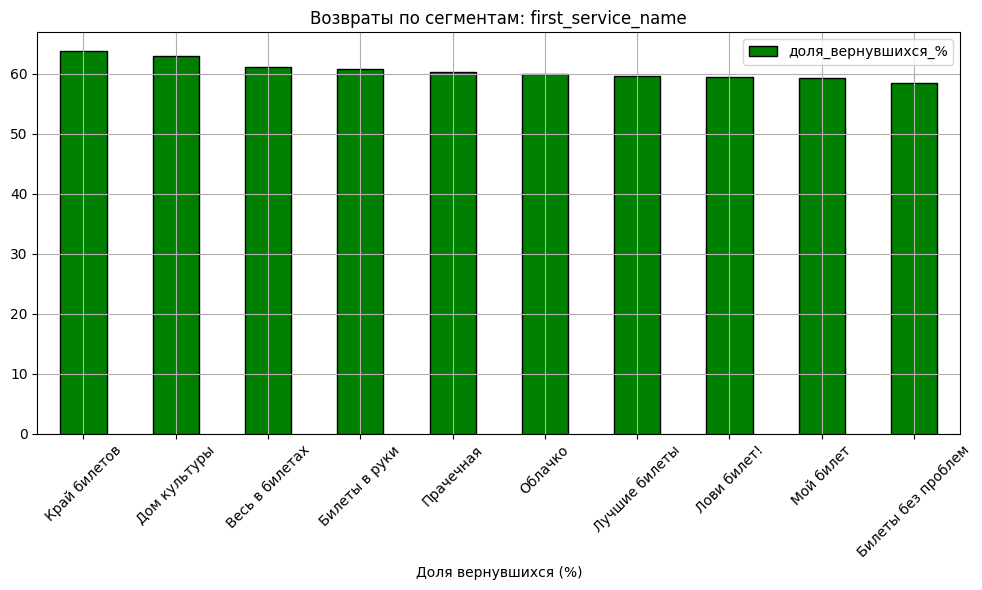

In [44]:
for column in first_order_features:
    # Группируем и считаем кол-во пользователей и долю вернувшихся
    result = df_profile_users_clean_p95.groupby(column)['is_two'].agg(['count', 'mean'])
    result.columns = ['пользователей', 'доля_вернувшихся']
    result['доля_вернувшихся_%'] = result['доля_вернувшихся'] * 100
    
    # Если это регион или оператор - оставляем только топ-10 по количеству пользователей
    if column in ['first_region_name', 'first_service_name']:
        result = result.sort_values('пользователей', ascending=False).head(10)
    
    # Сортируем по доле вернувшихся (для понятного вывода)
    result = result.sort_values('доля_вернувшихся_%', ascending=False)
    
    print(f"=== Возвраты по {column} ===")
    print(result[['пользователей', 'доля_вернувшихся_%']])
    print("\n")

    plt.figure(figsize=(10, 6))
    
    result['доля_вернувшихся_%'].plot(
    kind='bar',
    color='Green',
    edgecolor='black',
    grid=True
)

    plt.title(f'Возвраты по сегментам: {column}')
    plt.legend()
    plt.xlabel('Доля вернувшихся (%)')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

<div style="font-family: Arial, sans-serif; background: #f5f5f5; padding: 10px; border-radius: 8px">
    <b>Что получилось по возвратам:</b><br />
    <ul>
        <li>В среднем по выборке возвращаются <b>~60%</b> пользователей (делают ≥2 заказов).</li>
        <li>
            <b>Жанры:</b> чаще всех возвращаются после <b>выставок (63%)</b>, <b>театра (62%)</b>,
            <b>концертов (61%)</b>. Чуть хуже — спорт, ёлки, но их мало.
        </li>
        <li><b>Устройство:</b> с <b>десктопа</b> возвращаются чаще (<b>62%</b>), чем с мобилы (<b>59%</b>).</li>
        <li>
            <b>Регионы:</b> самые высокие возвраты у <b>Шанырского региона (66%)</b>,
            <b>Светополянского округа (64%)</b>, <b>Широковской области (63%)</b>. Крупные регионы (Каменевский,
            Североярская) тоже держатся около 61–62%.
        </li>
        <li>
            <b>Операторы:</b> лидеры — <b>«Край билетов» (64%)</b>, <b>«Дом культуры» (63%)</b>,
            <b>«Весь в билетах» (61%)</b>. Крупнейшие операторы дают возврат 58–60%, чуть ниже среднего.
        </li>
    </ul>
    <b> Вывод для маркетинга:</b><br />
    Успешные «точки входа» — это <b>выставки, театр, десктоп, а также регионы Шанырский и Светополянский</b>. Стоит
    крутить рекламу и делать акции именно на эти сегменты — оттуда пользователи чаще возвращаются. Операторы с высокой
    долей возврата (Край билетов, Дом культуры) хоть и маленькие, но тоже годятся для точечных коллабораций.
</div>


---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [45]:
filtered = df_profile_users_clean_p95[
    (df_profile_users_clean_p95['first_event_type_main'] == 'спорт') | 
    (df_profile_users_clean_p95['first_event_type_main'] == 'концерты')
]

# Группируем и считаем возвраты
result = filtered.groupby('first_event_type_main')['is_two'].agg(['count', 'mean'])
result.columns = ['пользователей', 'доля_вернувшихся']

print("=== Сравнение возвратов: концерты vs спорт ===")
print(result[['пользователей', 'доля_вернувшихся']])

=== Сравнение возвратов: концерты vs спорт ===
                       пользователей  доля_вернувшихся
first_event_type_main                                 
концерты                        9197          0.602914
спорт                            769          0.543563


In [46]:
# Группируем регионы: число пользователей и доля вернувшихся
region = df_profile_users_clean_p95.groupby('first_region_name')['is_two'].agg(['count', 'mean'])

# убираем мелкие значения (используем 'count')
region = region[region['count'] >= 10]
region['Доля вернувшихся'] = region['mean']

# Топ-10 и боттом-10 по количеству пользователей
top10 = region.sort_values('count', ascending=False).head(10)
bot10 = region.sort_values('count', ascending=False).tail(10)

print("=== Топ-10 регионов ===")
print(top10[['count', 'Доля вернувшихся']])
print("\n=== Боттом-10 регионов ===")
print(bot10[['count', 'Доля вернувшихся']])

avg_top = top10['Доля вернувшихся'].mean()
avg_bot = bot10['Доля вернувшихся'].mean()
print(f"\nСредняя доля возврата в топ-10: {avg_top:.3f}%")
print(f"Средняя доля возврата в боттом-10: {avg_bot:.3f}%")
print(f"Разница: {avg_top - avg_bot:.3f} п.п.")

=== Топ-10 регионов ===
                      count  Доля вернувшихся
first_region_name                            
Каменевский регион     6778          0.606816
Североярская область   3600          0.621389
Широковская область    1180          0.631356
Озернинский край        662          0.543807
Малиновоярский округ    516          0.550388
Травяная область        469          0.599147
Шанырский регион        463          0.645788
Светополянский округ    437          0.640732
Речиновская область     420          0.616667
Яблоневская область     400          0.582500

=== Боттом-10 регионов ===
                        count  Доля вернувшихся
first_region_name                              
Озернопольская область     27          0.888889
Горноземский регион        26          0.653846
Берестовский округ         22          0.636364
Радужнопольский край       21          0.761905
Белоярская область         17          0.588235
Лесоярская область         16          0.625000
Вишнёвский к

**Короткий вывод по гипотезам**

- **Гипотеза 1 (спорт vs концерты):** не подтвердилась. Фактически концерты дают возврат выше (60.6% против 54.4% у спорта).
- **Гипотеза 2 (активные регионы):** не подтвердилась. В топ‑10 крупных регионах возврат 60.6%, в боттом‑10 мелких – 64.0%. Разница в пользу мелких регионов, но там малые выборки (10–26 чел.), поэтому результат ненадёжен.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


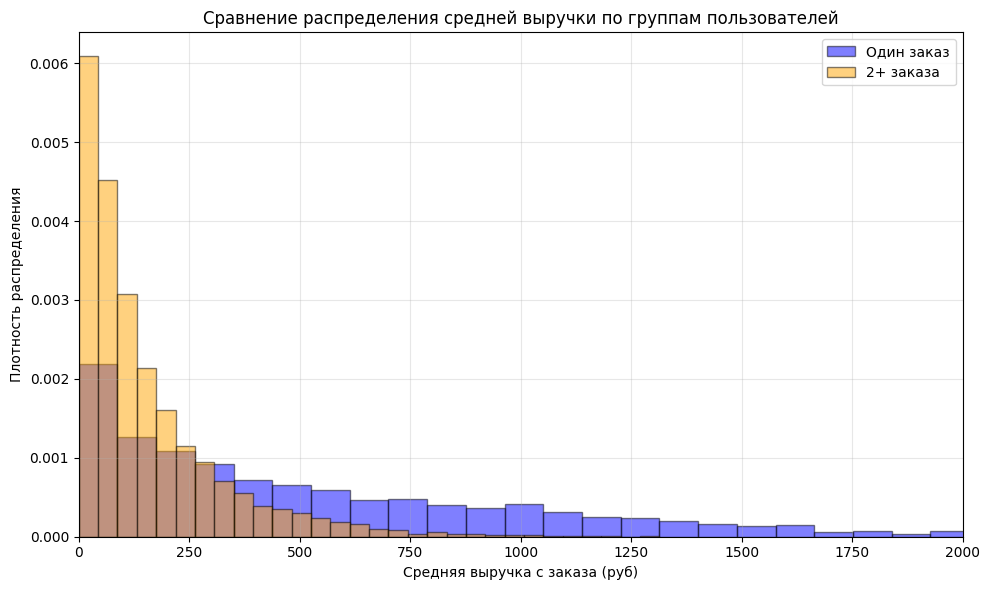

Группа с одним заказом:
count    8363.000000
mean      545.774760
std       519.402522
min         0.000000
25%       133.055000
50%       378.869995
75%       830.975006
95%      1577.800049
99%      2189.316392
max      2628.419922
Name: avg_revenue_rub, dtype: float64

Группа с 2+ заказами:
count    12384.000000
mean       155.356643
std        165.189424
min          0.000000
25%         41.024168
50%         98.488438
75%        210.085316
95%        504.441122
99%        761.724774
max       1314.209961
Name: avg_revenue_rub, dtype: float64


In [47]:
df_profile_users_clean_p95['avg_revenue_rub'] = df_profile_users_clean_p95['total_revenue'] / df_profile_users_clean_p95['total_orders']

# Группы: один заказ и вернувшиеся (2+ заказа)
one_order = df_profile_users_clean_p95[df_profile_users_clean_p95['total_orders'] == 1]['avg_revenue_rub']
returned = df_profile_users_clean_p95[df_profile_users_clean_p95['total_orders'] >= 2]['avg_revenue_rub']

# Гистограммы с density=True и одинаковыми bins
plt.figure(figsize=(10, 6))

one_order.plot(
    kind='hist',
    bins=30,
    alpha=0.5,
    density=True,
    color='blue',
    edgecolor='black',
    label='Один заказ'
)

returned.plot(
    kind='hist',
    bins=30,
    alpha=0.5,
    density=True,
    color='orange',
    edgecolor='black',
    label='2+ заказа'
)

plt.xlim(0, 2000)
plt.xlabel('Средняя выручка с заказа (руб)')
plt.ylabel('Плотность распределения')
plt.title('Сравнение распределения средней выручки по группам пользователей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Статистики
print("Группа с одним заказом:")
print(one_order.describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))
print("\nГруппа с 2+ заказами:")
print(returned.describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

<div style="background: #f2f2f2; padding: 10px; border-radius: 8px; font-family: sans-serif;">
  <strong>Выводы связи между средней выручкой сервиса с заказа и повторными заказами</strong>
  <ul>
    <li>
      <strong>Диапазоны заказов:</strong><br>
      – Пользователи с <strong>одним заказом</strong> чаще всего имеют среднюю выручку в интервале <strong>130–840 руб</strong> (25–75 перцентили), медиана около <strong>380 руб</strong>.<br>
      – Пользователи с <strong>2+ заказами</strong> концентрируются в более низком диапазоне: <strong>42–215 руб</strong>, медиана около <strong>100 руб</strong>.
    </li>
    <li>
      <strong>Различия между группами:</strong><br>
      – Группа «один заказ» отличается <strong>значительно более высокой средней выручкой</strong> (медиана 382 руб против 100 руб у вернувшихся).<br>
      – Разброс также выше у групп пользователей с одним заказом (629 против 196), что говорит о большем разнообразии сумм.<br>
      – 95-й и 99-й перцентили показывают, что даже на верхних границах пользователи с одним заказом тратят в 2–3 раза больше (1600–2600 руб против 530–860 руб у вернувшихся).
    </li>
  </ul>
  <p><strong>Общий вывод:</strong> Гипотеза, что «более дорогие заказы = чаще возвращаются» <strong>не подтверждается</strong>. Наоборот, пользователи, которые делают повторные заказы, тратят в среднем <strong>меньше</strong> на один заказ. Возможно, они чаще покупают недорогие билеты, но делают это систематически. Группа пользователей с одним заказом это клиенты которые могут разово позволить себе дорогой билет, но не возвращаются.</p>
</div>

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


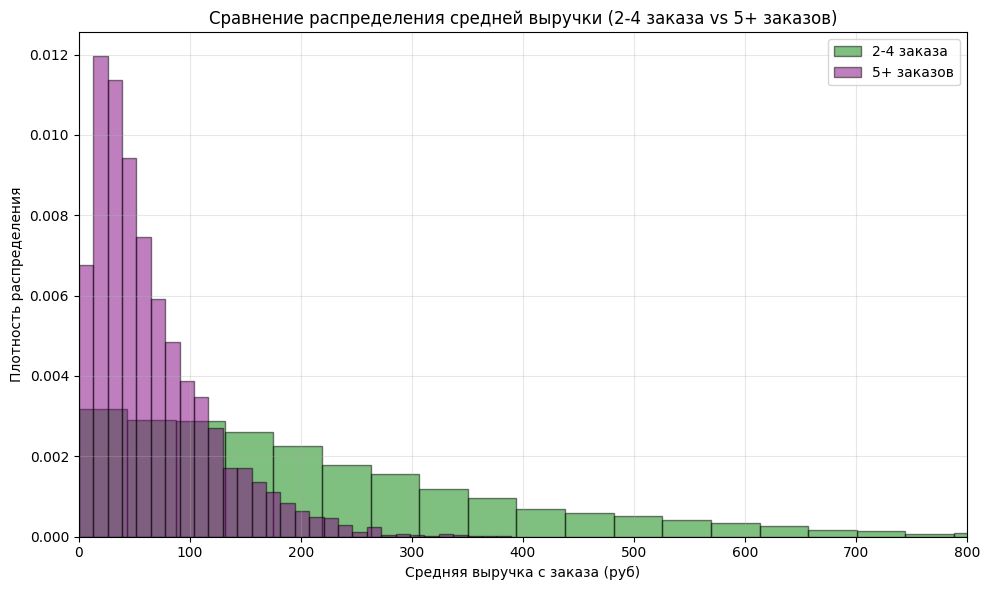

=== Группа 2–4 заказа ===
count    7143.000000
mean      220.889868
std       187.181475
min         0.000000
25%        82.773746
50%       172.904999
75%       306.114990
95%       591.657294
99%       856.612736
max      1314.209961
Name: avg_revenue_rub, dtype: float64

=== Группа 5+ заказов ===
count    5241.000000
mean       66.040897
std        53.828093
min         0.000000
25%        26.380771
50%        50.275151
75%        90.904469
95%       175.562238
99%       240.539277
max       389.165967
Name: avg_revenue_rub, dtype: float64


In [48]:
# Фильтруем группы
group2_4 = df_profile_users_clean_p95[
    (df_profile_users_clean_p95['total_orders'] >= 2) & 
    (df_profile_users_clean_p95['total_orders'] <= 4)]['avg_revenue_rub']

group5plus = df_profile_users_clean_p95[
    df_profile_users_clean_p95['total_orders'] >= 5]['avg_revenue_rub']

# Гистограммы (ось X ограничим до 800 для более чёткого отображения)
plt.figure(figsize=(10, 6))

group2_4.plot(
    kind='hist',
    bins=30,
    alpha=0.5,
    density=True,
    color='green',
    edgecolor='black',
    label='2-4 заказа'
)

group5plus.plot(
    kind='hist',
    bins=30,
    alpha=0.5,
    density=True,
    color='purple',
    edgecolor='black',
    label='5+ заказов'
)

plt.xlim(0, 800)
plt.xlabel('Средняя выручка с заказа (руб)')
plt.ylabel('Плотность распределения')
plt.title('Сравнение распределения средней выручки (2-4 заказа vs 5+ заказов)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Статистики с перцентилями
print("=== Группа 2–4 заказа ===")
print(group2_4.describe(percentiles=[.25, .5, .75, .95, .99]))
print("\n=== Группа 5+ заказов ===")
print(group5plus.describe(percentiles=[.25, .5, .75, .95, .99]))

<div style="background: #f2f2f2; padding: 10px; border-radius: 8px; font-family: sans-serif">
    <strong>Выводы по сравнению групп 2–4 заказа и 5+ заказов:</strong>
    <ul>
        <li>
            <strong>Сравнение групп по средней выручке на заказ:</strong><br />
            – Группа <strong>2–4 заказа</strong> (7155 человек): медиана = <strong>175 руб</strong>, 25–75 перцентили:
            <strong>83–312 руб</strong>, среднее = <strong>232 руб</strong>.<br />
            – Группа <strong>5+ заказов</strong> (5325 человек): медиана = <strong>52 руб</strong>, 25–75 перцентили:
            <strong>27–96 руб</strong>, среднее = <strong>71 руб</strong>.
        </li>
        <li>
            <strong>Различия между группами:</strong><br />
            – Пользователи с 5+ заказами тратят на один заказ <strong>в 3-4 раза меньше</strong>, чем пользователи из
            группы 2–4 заказа.<br />
            – Разброс в группе 5+ заказов значительно ниже (66 против 230), то есть их
            поведение более равномерно они почти всегда покупают недорогие билеты.<br />
            – 95-й и 99-й перцентили также намного ниже у самой активной группы (190–297 руб против 632–970 руб у группы
            2–4 заказа).
        </li>
    </ul>
    <p>
        <strong>Ответ на вопрос задачи:</strong> Да, различия ярко выражены. Чем больше заказов совершает
        пользователь, тем <strong>ниже</strong> его средняя выручка на один заказ. Гипотеза, что «активные пользователи
        приносят больше денег за заказ», не подтверждается – наоборот, они выбирают более дешёвые мероприятия, но делают
        это очень часто.
    </p>
</div>


---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [49]:
print("=== Общее распределение среднего числа билетов в заказе ===")
print(df_profile_users_clean_p95['mean_tickets'].describe(percentiles=[.25, .5, .75, .95, .99]))

=== Общее распределение среднего числа билетов в заказе ===
count    20747.000000
mean         2.744537
std          0.934517
min          1.000000
25%          2.000000
50%          2.750000
75%          3.153846
95%          4.000000
99%          5.000000
max         11.000000
Name: mean_tickets, dtype: float64


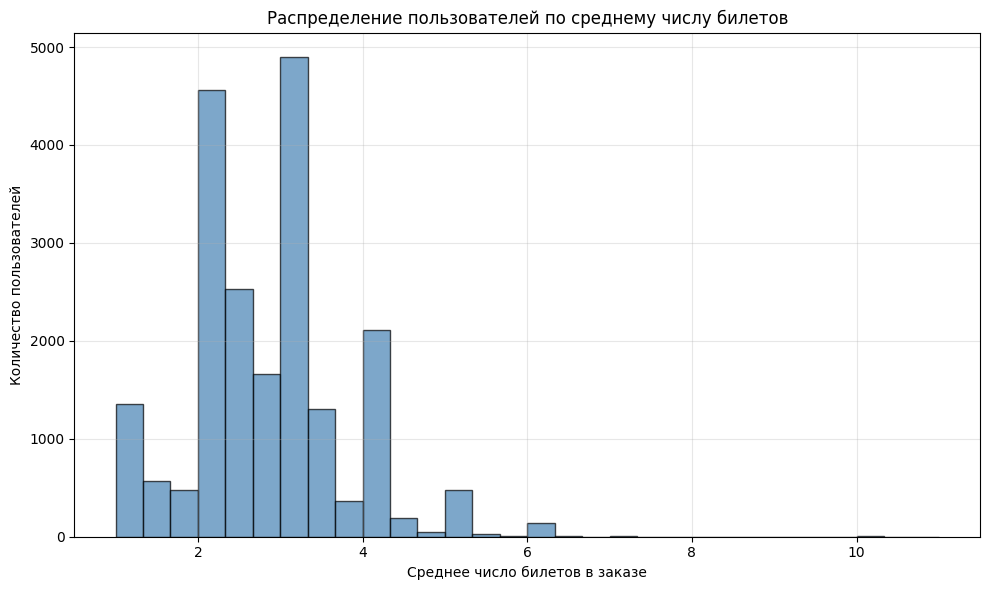

In [50]:
plt.figure(figsize=(10, 6))

df_profile_users_clean_p95['mean_tickets'].plot(
    kind='hist',
    bins=30,
    edgecolor='black',
    alpha=0.7,
    color='steelblue'
)

plt.xlabel('Среднее число билетов в заказе')
plt.ylabel('Количество пользователей')
plt.title('Распределение пользователей по среднему числу билетов')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Основные наблюдения по распределению `avg_tickets_count`**

- Среднее значение: **2.76**, медиана: **2.78** данные почти идентичны.
- 75% пользователей имеют среднее число билетов меньше **3.2**, т.е. обычный диапазон билетов (2–3 билета).
- Пользователей с 4+ билетами всего 5%,
- Пользователей с 5+ это 1% (максимум 12).
- Минимум 1 билет (одиночные покупатели).

In [51]:
# Сегментация
bins = [1, 2, 3, 5, 100]  # левые границы включительно, правые не включены для последнего
labels = ['1-2 билета', '2-3 билета', '3-5 билетов', '5+ билетов']
tickets_segment = pd.cut(df_profile_users_clean_p95['mean_tickets'], bins=bins, labels=labels, right=False)

# Агрегация по сегментам
segment_stats = df_profile_users_clean_p95.groupby(tickets_segment)['is_two'].agg(['count', 'mean'])
segment_stats.columns = ['пользователей', 'Доля вернувшихся']

print("\nСегменты по среднему числу билетов:")
print(segment_stats)


Сегменты по среднему числу билетов:
              пользователей  Доля вернувшихся
mean_tickets                                 
1-2 билета             2406          0.511638
2-3 билета             8752          0.713437
3-5 билетов            8928          0.535954
5+ билетов              661          0.187595


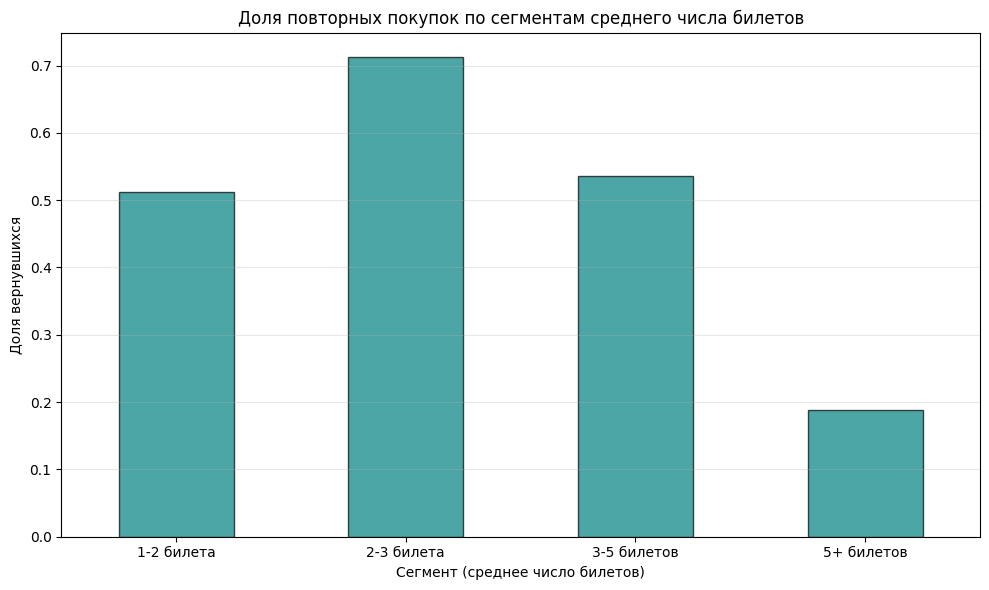

In [52]:
plt.figure(figsize=(10, 6))

segment_stats['Доля вернувшихся'].plot(
    kind='bar',
    color='teal',
    edgecolor='black',
    alpha=0.7
)

plt.xlabel('Сегмент (среднее число билетов)')
plt.ylabel('Доля вернувшихся')
plt.title('Доля повторных покупок по сегментам среднего числа билетов')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

<div style="background: #f2f2f2; padding: 10px; border-radius: 8px; font-family: sans-serif">
    <strong> Ответы на вопросы по сегментам среднего числа билетов</strong>
    <ul>
        <li>
            <strong>Равномерность распределения пользователей по сегментам:</strong><br />
            Распределение <strong>неравномерное</strong>. Основная масса пользователей сосредоточена в двух средних
            сегментах: <strong>2–3 билета</strong> (8717 чел.) и <strong>3–5 билетов</strong> (9055 чел.). Сегмент
            <strong>1–2 билета</strong> значительно меньше (2388), а сегмент <strong>5+ билетов</strong> – очень
            маленький (689 чел.).
        </li>
        <li>
            <strong>Аномально высокие/низкие доли повторных покупок:</strong><br />
            – <strong>Аномально высокая</strong> доля возврата в сегменте <strong>2–3 билета</strong> –
            <strong>71,4%</strong>.<br />
            – <strong>Аномально низкая</strong> доля возврата в сегменте <strong>5+ билетов</strong> –
            <strong>19,3%</strong>.<br />
            – Сегменты 1–2 билета и 3–5 билетов показывают средний возврат около 51–54%, что близко к общему среднему
            (около 60%).
        </li>
    </ul>
    <p>
        <strong>Вывод:</strong> Наиболее лояльная группа покупатели <strong>2–3 билетов</strong> (скорее всего, пары
        или небольшие компании). Пользователи, которые стабильно берут 5+ билетов (групповые походы), почти не
        возвращаются. Возможно, это организаторы или разовые акции.
    </p>
</div>


---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [53]:
weekday =  df_profile_users_clean_p95['first_date'].dt.dayofweek
# Названия дней
weekday_names = ['пн', 'вт', 'ср', 'чт', 'пт', 'сб', 'вс']

weekday_stats = df_profile_users_clean_p95.groupby(weekday)['is_two'].agg(['count', 'mean'])
weekday_stats.columns = ['пользователей', 'Доля вернувшихся']
weekday_stats.index = weekday_names  

print("=== День недели первого заказа ===")
print(weekday_stats)

=== День недели первого заказа ===
    пользователей  Доля вернувшихся
пн           2813          0.616068
вт           3024          0.599868
ср           2960          0.609797
чт           3026          0.582948
пт           3163          0.585836
сб           3120          0.603526
вс           2641          0.580083


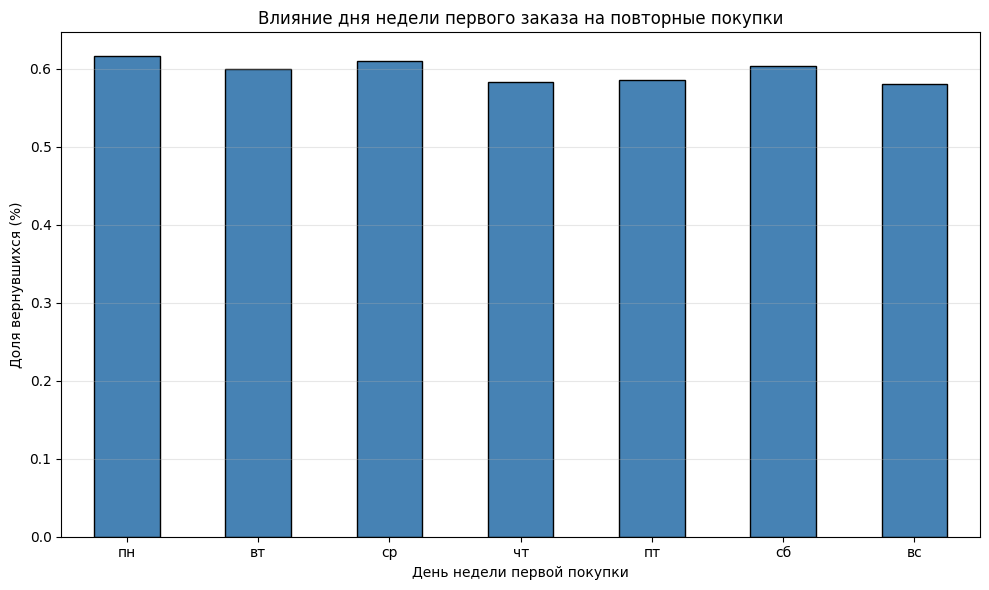

In [54]:
plt.figure(figsize=(10, 6))

weekday_stats['Доля вернувшихся'].plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.xlabel('День недели первой покупки')
plt.ylabel('Доля вернувшихся (%)')
plt.title('Влияние дня недели первого заказа на повторные покупки')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

<div style="background: #f2f2f2; padding: 10px; border-radius: 8px; font-family: sans-serif">
    <strong> Вывод по влиянию дня недели первой покупки:</strong>
    <ul>
        <li>
            Распределение первых заказов по дням недели примерно равномерное (от 2654 в воскресенье до 3182 в пятницу).
        </li>
        <li>
            Доля вернувшихся колеблется в диапазоне <strong>58,2% – 61,8%</strong>:
            <li>Максимальный возврат в <strong>понедельник (61,8%)</strong> и <strong>среду (61,2%)</strong>.</li>
            <li>Минимальный в <strong>воскресенье (58,2%)</strong> и <strong>четверг (58,4%)</strong>.</li>
        </li>
        <li>
            Разница между максимальным и минимальным значением составляет <strong>~3,6 процента</strong> это
            не очень большое различие, но оно указывает на некоторую неравномерность.
        </li>
    </ul>
    <p>
        <strong>Ответ на вопрос:</strong> День недели слабо, но влияет на вероятность возврата. Пользователи,
        совершившие первую покупку в <strong>понедельник или среду</strong>, возвращаются чуть чаще, чем те, кто начинал
        в выходные или четверг. Однако разница не настолько велика.
    </p>
</div>


---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [55]:
group_2_4 = df_profile_users_clean_p95[
    (df_profile_users_clean_p95['total_orders'] >= 2) & 
    (df_profile_users_clean_p95['total_orders'] <= 4)]['mean_days_since_prev']

group_5_and_more = df_profile_users_clean_p95[df_profile_users_clean_p95['total_orders'] >= 5]['mean_days_since_prev']

print("=== Группа 2–4 заказа (средний интервал, дни) ===")
print(group_2_4.describe(percentiles=[.25, .5, .75, .95, .99]))

print("\n=== Группа 5+ заказов (средний интервал, дни) ===")
print(group_5_and_more.describe(percentiles=[.25, .5, .75, .95, .99]))


=== Группа 2–4 заказа (средний интервал, дни) ===
count    7143.000000
mean       21.328678
std        28.485071
min         0.000000
25%         0.000000
50%         9.000000
75%        34.000000
95%        84.000000
99%       125.000000
max       148.000000
Name: mean_days_since_prev, dtype: float64

=== Группа 5+ заказов (средний интервал, дни) ===
count    5241.000000
mean       11.130317
std         7.775420
min         0.000000
25%         5.592593
50%         9.555555
75%        15.375000
95%        26.750000
99%        33.500000
max        37.500000
Name: mean_days_since_prev, dtype: float64


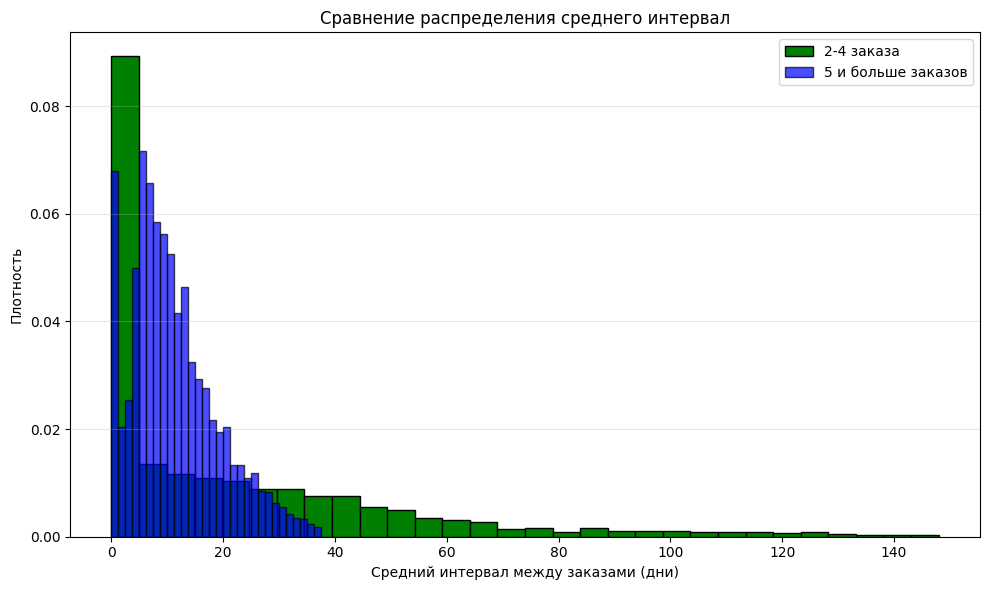

In [56]:
plt.figure(figsize=(10, 6))

group_2_4.plot(
    kind='hist',
    bins=30,
    color='green',
    label='2-4 заказа',
    density=True,
    edgecolor='black'
)

group_5_and_more.plot(
    kind='hist',
    bins=30,
    color='blue',
    density=True,
    alpha=0.7,
    label='5 и больше заказов',
    edgecolor='black'
)


plt.xlabel('Средний интервал между заказами (дни)')
plt.ylabel('Плотность')
plt.title('Сравнение распределения среднего интервал')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)

plt.legend()

plt.tight_layout()
plt.show()

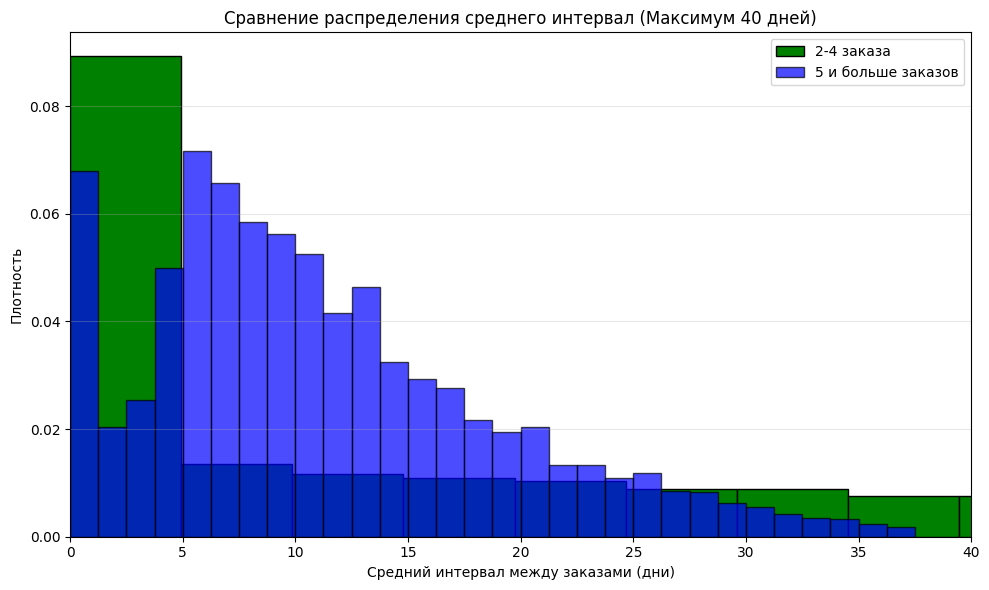

In [57]:
plt.figure(figsize=(10, 6))

group_2_4.plot(
    kind='hist',
    bins=30,
    color='green',
    label='2-4 заказа',
    density=True,
    edgecolor='black'
)

group_5_and_more.plot(
    kind='hist',
    bins=30,
    color='blue',
    density=True,
    alpha=0.7,
    label='5 и больше заказов',
    edgecolor='black'
)


plt.xlabel('Средний интервал между заказами (дни)')
plt.ylabel('Плотность')
plt.title('Сравнение распределения среднего интервал (Максимум 40 дней)')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)

plt.legend()
plt.xlim(0, 40)  # ограничие для наглядности

plt.tight_layout()
plt.show()

<div style="background: #f2f2f2; padding: 10px; border-radius: 8px; font-family: sans-serif">
    <strong>Вывод по влиянию интервала между заказами:</strong>
    <ul>
        <li>
            <strong>Группа 2–4 заказа</strong>: средний интервал ~ <strong>21 день</strong>, медиана
            <strong>9 дней</strong>, но разброс велик (25% пользователей имеют 0 дней – то есть заказы в один день, а
            75% – до 34 дней). Есть длинный хвост до 148 дней.
        </li>
        <li>
            <strong>Группа 5+ заказов</strong>: интервал значительно <strong>короче и стабильнее</strong>: среднее ~
            <strong>11 дней</strong>, медиана <strong>9.5 дней</strong>, 75-й перцентиль всего 15.4 дня, максимум 37.5
            дней. У них практически нет огромных пауз.
        </li>
    </ul>
    <p>
        <strong>Рекомендация:</strong> стимулировать сокращение интервала между заказами, бонусы за
        повторную покупку в течение 7 дней, персонализированные рекомендации событий, которые происходят в ближайшее
        время. Клиентов с интервалом более 30 дней нужно «возвращать» специальными предложениями.
    </p>
</div>


---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [58]:
n_columns = [
    'total_orders',
    'first_device',
    'first_region_name',
    'first_service_name',
    'first_event_type_main',
    'mean_tickets',
    'mean_days_since_prev',
    'avg_revenue_rub',
    'weekday']

df_profile_users_clean_p95['weekday'] = weekday

interval_cols = ['total_orders', 'mean_tickets', 'mean_days_since_prev', 'avg_revenue_rub', 'weekday']
phi_corr = df_profile_users_clean_p95[n_columns].phik_matrix(interval_cols=interval_cols)

phi_corr['total_orders'].drop('total_orders').sort_values(ascending=False)

mean_days_since_prev     0.490139
avg_revenue_rub          0.458995
mean_tickets             0.296849
first_device             0.051309
first_service_name       0.041140
first_event_type_main    0.027128
first_region_name        0.026952
weekday                  0.019044
Name: total_orders, dtype: float64

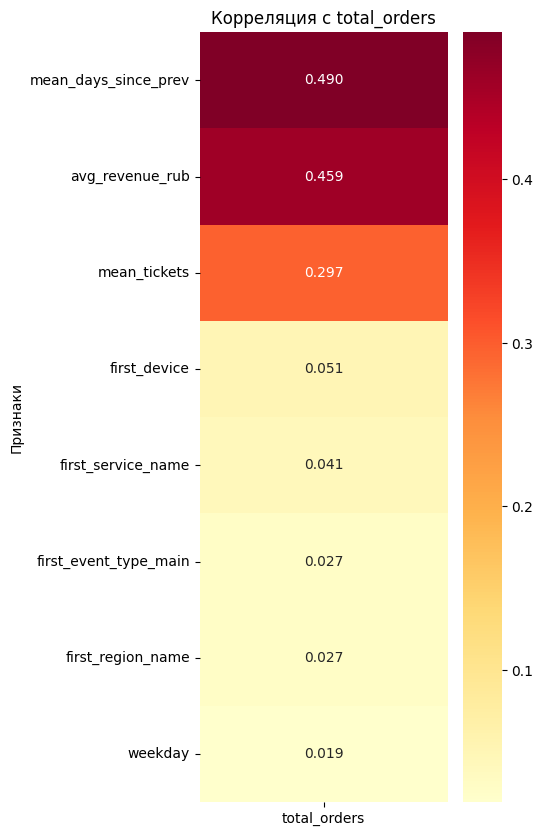

In [59]:
corr_series = phi_corr['total_orders'].drop('total_orders').sort_values(ascending=False)
corr_df = pd.DataFrame(corr_series)

plt.figure(figsize=(4, 10))
sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='YlOrRd', cbar=True)

plt.title('Корреляция с total_orders')
plt.ylabel('Признаки')
plt.show()

In [60]:
def strength(phi):
    if phi < 0.05:
        return 'Отсутствует'
    elif phi < 0.2:
        return 'Очень слабая'
    elif phi < 0.4:
        return 'Слабая'
    elif phi < 0.6:
        return 'Средняя'
    else:
        return 'Сильная'

# Без предположения о наличии индекса 'total_orders'
corr_series = phi_corr['total_orders'].drop('total_orders')
for col, val in corr_series.sort_values(ascending=False).items():
    print(f"{col}: {round(val,3)} - {strength(val)} сила связи")

mean_days_since_prev: 0.49 - Средняя сила связи
avg_revenue_rub: 0.459 - Средняя сила связи
mean_tickets: 0.297 - Слабая сила связи
first_device: 0.051 - Очень слабая сила связи
first_service_name: 0.041 - Отсутствует сила связи
first_event_type_main: 0.027 - Отсутствует сила связи
first_region_name: 0.027 - Отсутствует сила связи
weekday: 0.019 - Отсутствует сила связи


Сегмент 1 заказ пропущен (total_orders константа)

=== Сегмент 2-4 заказа ===
mean_days_since_prev: 0.385 - Слабая сила связи
mean_tickets: 0.369 - Слабая сила связи
avg_revenue_rub: 0.361 - Слабая сила связи
first_service_name: 0.062 - Очень слабая сила связи
first_device: 0.007 - Отсутствует сила связи
first_region_name: 0.0 - Отсутствует сила связи
first_event_type_main: 0.0 - Отсутствует сила связи
weekday: 0.0 - Отсутствует сила связи





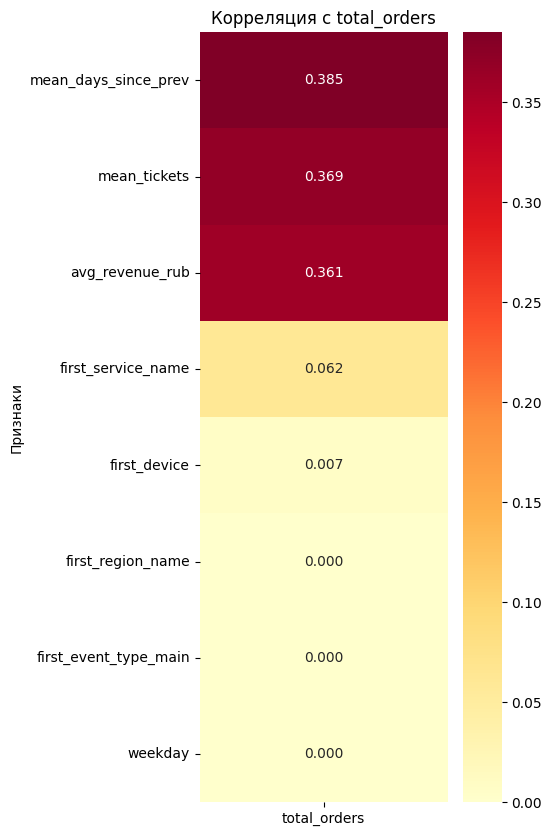


=== Сегмент 5+ заказов ===
mean_days_since_prev: 0.713 - Сильная сила связи
avg_revenue_rub: 0.589 - Средняя сила связи
mean_tickets: 0.119 - Очень слабая сила связи
first_service_name: 0.092 - Очень слабая сила связи
first_region_name: 0.069 - Очень слабая сила связи
first_event_type_main: 0.051 - Очень слабая сила связи
first_device: 0.035 - Отсутствует сила связи
weekday: 0.0 - Отсутствует сила связи





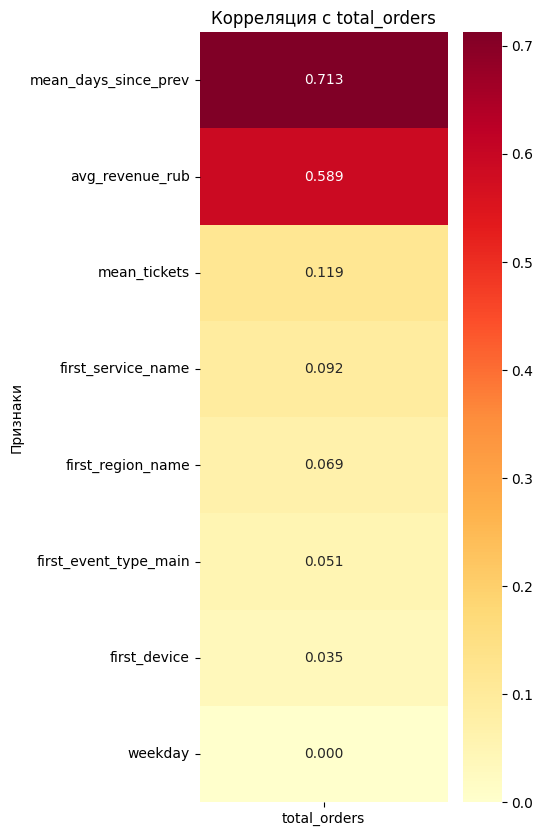

In [61]:
bins_orders = [0, 1, 4, 1000000]
labels_orders = ['1 заказ', '2-4 заказа', '5+ заказов']

df_profile_users_clean_p95['order_segment'] = pd.cut(df_profile_users_clean_p95['total_orders'], bins=bins_orders, labels=labels_orders, right=True)

# Перебираем сегменты
for seg in df_profile_users_clean_p95['order_segment'].unique():
    if seg == '1 заказ':
        print(f"Сегмент {seg} пропущен (total_orders константа)")
        continue
    phik_seg = df_profile_users_clean_p95[df_profile_users_clean_p95['order_segment'] == seg][n_columns].phik_matrix(interval_cols=interval_cols)

    print(f"\n=== Сегмент {seg} ===")
    corr_series = phik_seg['total_orders'].drop('total_orders')
    for col, val in corr_series.sort_values(ascending=False).items():
        print(f"{col}: {round(val,3)} - {strength(val)} сила связи")

    print('\n\n')
    corr_series = corr_series.sort_values(ascending=False)
    corr_df = pd.DataFrame(corr_series)
    
    plt.figure(figsize=(4, 10))
    sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='YlOrRd', cbar=True)
    
    plt.title('Корреляция с total_orders')
    plt.ylabel('Признаки')
    plt.show()

<div style="background: #f2f2f2; padding: 10px; border-radius: 8px; font-family: sans-serif">
    <strong>Корреляция признаков с количеством заказов: (<code>total_orders</code>)</strong>
    <ul>
        <li>
            <strong>Все пользователи</strong>: основные взаимосвязи — <code>mean_days_since_prev</code> (0.47, умеренная
            связь) и <code>mean_tickets</code> (0.31, слабая). Остальные признаки (выручка, устройство, регион,
            оператор, жанр, день недели) практически не связаны (0.07).
        </li>
        <li>
            <strong>Сегмент 2–4 заказа</strong>: умеренные связи у <code>mean_days_since_prev</code> (0.39),
            <code>mean_tickets</code> (0.37) и <code>avg_revenue_rub</code> (0.32). Категориальные признаки незначительны.
        </li>
        <li>
            <strong>Сегмент 5+ заказов</strong>: очень сильная связь с <code>mean_days_since_prev</code> (0.72) — чем
            меньше интервал, тем больше заказов. Умеренная связь с <code>avg_revenue_rub</code> (0.31), связь с
            <code>mean_tickets</code> слабая (0.13). Категориальные признаки не влияют.
        </li>
    </ul>
    <p>
        <strong>Вывод</strong>: главный фактор, определяющий количество заказов —
        <strong>частота покупок</strong> (короткий интервал между заказами). Средняя выручка и количество билетов вносят
        вклад, но значительно меньший. Регион, устройство, оператор, жанр и день недели практически не имеют значения.
    </p>
    <p>
        <strong>Рекомендация</strong>: Сокрщать интервал между покупками (акции «вернись
        в течение 7 дней», персональные предложения на ближайшие события). Работа с категориальными признаками не даст
        ощутимого эффекта.
    </p>
</div>


### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

<div style="background: #f2f2f2; padding: 10px; border-radius: 8px; font-family: sans-serif">
    <strong> Общий вывод и рекомендации по проекту</strong>
    <ul>
        <li>
            <strong>Данные и подготовка</strong><br />
            Исходная выборка: <strong>290 611 заказов</strong> от <strong>21 933 пользователей</strong> за 2024 год.
            Валюту привели к рублям (<code>revenue_rub</code>), отфильтровали выбросы по 99‑му перцентилю выручки
            (удалили ~1% записей). Типы данных оптимизированы, пропуски – только в <code>days_since_prev</code>
            (первые покупки). Построен профиль каждого пользователя (даты, жанр, устройство, регион, оператор, средний
            чек, среднее число билетов, интервал между заказами).
        </li>
        <li>
            <strong>Основные результаты анализа</strong><br />
            – Доля вернувшихся (больше 2 заказов) <strong>~60%</strong>. <br />
            – Самые популярные жанры при первом заказе: <strong>выставки (63%)</strong>, театр (62%), концерты (61%); спорт и ёлки
            ниже (54%). <br />
            – Пользователи с <strong>десктопа</strong> возвращаются чаще (62% против 59% у мобильных). <br />
            – Регионы‑лидеры по возврату: Шанырский (66%), Светополянский (64%), Широковская область (63%). <br />
            – <strong>Средняя выручка на заказ у вернувшихся (163 руб) значительно ниже</strong>, чем у одноразовых (567
            руб) лояльные покупают чаще, но заказы дешевле. <br />
            – Сегмент <strong>2–3 билета в заказе</strong> самый массовый и лояльный (71% возврата). Сегмент 5+
            билетов даёт лишь 19% возврата (скорее разовые групповые покупки). <br />
            – <strong>Интервал между заказами</strong> главный маркер активности: у группы 5+ заказов средний интервал
            <strong>11 дней</strong> (медиана 9,5), у группы 2–4 заказа 21 день (медиана 9). <br />
            – Корреляционный анализ <code>phik_matrix</code> подтверждает, что
            <strong>количество заказов сильнее всего связано с <code>mean_days_since_prev</code> (0,47–0,72)</strong>,
            затем с <code>mean_tickets</code> (0,31). Категориальные признаки (регион, устройство, оператор, жанр, день
            недели) имеют нулевую или очень слабую связь (0,07).
        </li>
        <li>
            <strong>Главный вывод</strong><br />
            Наиболее эффективный способ увеличить повторные заказы это <strong>сокращать интервал между покупками</strong>
            и побуждать пользователей возвращаться в течение 1–2 недель. Высокая выручка с заказа не гарантирует
            лояльности. Жанровые и географические особенности не значительны.
        </li>
    </ul>
    <p>
        <li>
        <strong>Рекомендации для маркетинга</strong><br />
        – Запустите <strong>«быстрые» акции</strong>: бонусы за повторный заказ в течение 7 дней, персонализированные
        предложения на ближайшие события.<br />
        – Усильте <strong>выставки и театр</strong> в первом заказе, они дают лучший возврат.<br />
        – Инвестируйте в <strong>десктопную версию</strong> и регионы‑лидеры (Шанырский, Светополянский, Широковская
        область).<br />
        – Не переоценивайте категориальные признаки (устройство, оператор, жанр) они слабо влияют на частоту
        заказов.<br />
        – Следует проанализировать пользователей с большим количеством заказов (>150 заказов) отдельно, не следует ореинтироваться на них в массовых
        стратегиях.
        </li>
    </p>
    <p style="background: #e0e0e0; padding: 6px; border-radius: 6px">
        <strong>Резюме</strong>: частота покупок важнее суммы выручки. Следует применить стратегию вокруг сокращения интервала между
        заказами, а не вокруг увеличения разовой выручки.
    </p>
</div>


### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**

Ссылка на GitHub: https://github.com/VisteN2203/Project-DS2